# CSBS Supervised Learning — Predicting Breach Outcome
**Author:** Toby Beevers  
**Purpose:** Binary classification — predict whether a business experienced a cyber breach, using governance, policy, and technical controls as features.

### Research question
> *Can observable organisational behaviours (board priority, governance actions, security policies, technical controls) predict whether a business will experience a cyber breach?*

### Approach
- **Target variable:** `breached` (1 = experienced a breach, 0 = did not)
- **Features:** 24 variables covering governance, policy, and technical controls (same stable core as the cluster analysis, minus the target)
- **Models compared:** Logistic Regression, Decision Tree, Random Forest
- **Evaluation:** Train/test split, accuracy, F1, confusion matrix, ROC-AUC curve
- **Interpretation:** Feature importance — which behaviours best predict breach risk?

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

## 2. Load survey data

Same loading pattern as the cluster analysis notebook — tab-delimited `.tab` files, one per wave (2018–2025). `normalise_columns()` strips BOM characters and whitespace from column headers, which vary slightly between waves.

`PROJECT_ROOT` is derived from `Path.cwd().parent` — this notebook must be run with its kernel CWD set to the `machine learning/` directory.

In [2]:
PROJECT_ROOT = Path.cwd().parent

GOVERNANCE_VARS = ['manage1', 'manage2', 'manage3', 'manage4', 'manage6', 'manage7']
POLICY_VARS     = ['policy1', 'policy2', 'policy3', 'policy4', 'policy5', 'policy8', 'policy9']
CONTROLS_VARS   = ['step1', 'step2', 'step3', 'step4', 'step5',
                   'step6', 'step7', 'step8', 'step9', 'step10']

# Features used to predict breach — all except the target itself
FEATURE_COLS = ['priority_score'] + GOVERNANCE_VARS + POLICY_VARS + CONTROLS_VARS
TARGET_COL   = 'breached'
META_COLS    = ['year', 'sizeb']

MISSING_CODES = [-1, -97, -98, -99]

def normalise_columns(df):
    df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False).str.lower()
    return df

raw = {}
for year in range(2018, 2026):
    path = PROJECT_ROOT / 'data_raw' / f'{year}.tab'
    df = pd.read_csv(path, sep='\t', low_memory=False)
    df = normalise_columns(df)
    df['year'] = year
    raw[year] = df

print(f"Loaded {len(raw)} waves:")
for y, df in raw.items():
    print(f"  {y}: {len(df):,} rows, {df.shape[1]:,} columns")

Loaded 8 waves:
  2018: 2,088 rows, 462 columns
  2019: 2,080 rows, 462 columns
  2020: 1,900 rows, 313 columns
  2021: 2,284 rows, 421 columns
  2022: 2,157 rows, 447 columns
  2023: 3,991 rows, 568 columns
  2024: 3,434 rows, 499 columns
  2025: 3,835 rows, 528 columns


## 3. Clean and engineer features

Identical cleaning logic to the cluster notebook:
- **Businesses only** (`samptype == 1`) — org size (`sizeb`) is only meaningful for this group
- **Policy routing fix** — `policy1–5` are `-1` (routing, not missing) when `manage3 == 0`; recode to `0` before the missing-code sweep
- **Standard missing codes** (`-1`, `-97`, `-98`, `-99`) → `NaN`
- **`priority` 2025 quirk** — whitelist to `{1,2,3,4}` to exclude `997` (DK); invert to `priority_score` so higher = higher board priority
- **`type11` 2025 quirk** — whitelist to `{0,1}` to exclude `-9`; recode `type11==0` → `breached=1`

Sanity check: breach rates should be 40–60% per year. Values above 90% mean the missing-code filters failed.

In [3]:
def prepare_wave(df):
    df = df.copy()
    df = df[df['samptype'] == 1].copy()

    # Policy routing: -1 when manage3==0 means policy doesn't exist → recode to 0
    if 'manage3' in df.columns:
        no_policy = df['manage3'] == 0
        for col in ['policy1', 'policy2', 'policy3', 'policy4', 'policy5']:
            if col in df.columns:
                df.loc[no_policy & (df[col] == -1), col] = 0

    # Standard missing codes → NaN
    df = df.replace(MISSING_CODES, np.nan)

    # priority: whitelist {1,2,3,4}; invert so higher score = higher priority
    if 'priority' in df.columns:
        df['priority'] = df['priority'].where(df['priority'].isin([1, 2, 3, 4]))
        df['priority_score'] = 5 - df['priority']

    # type11: whitelist {0,1}; type11==0 means breached
    if 'type11' in df.columns:
        df['type11'] = df['type11'].where(df['type11'].isin([0, 1]))
        df['breached'] = (df['type11'] == 0).astype(float)
        df.loc[df['type11'].isna(), 'breached'] = np.nan

    return df

cleaned = {year: prepare_wave(df) for year, df in raw.items()}

print("Sanity check — breach rate per wave (expect 40–60%):")
for y, df in cleaned.items():
    breach_pct = df['breached'].mean() * 100
    print(f"  {y}: {len(df):,} businesses | breach rate {breach_pct:.1f}%")

Sanity check — breach rate per wave (expect 40–60%):
  2018: 1,519 businesses | breach rate 52.1%
  2019: 1,615 businesses | breach rate 42.1%
  2020: 1,374 businesses | breach rate 57.5%
  2021: 1,448 businesses | breach rate 47.2%
  2022: 1,265 businesses | breach rate 47.3%
  2023: 2,413 businesses | breach rate 41.2%
  2024: 2,000 businesses | breach rate 57.6%
  2025: 2,180 businesses | breach rate 53.5%


## 4. Build feature matrix and target vector

All 8 waves are stacked into one combined dataset. The feature matrix `X` contains 24 predictor variables; `y` is the binary breach target.

Rows where `breached` is NaN are dropped — we can only train on observations where the target is known. `year` and `sizeb` are kept as metadata for later analysis but are **not** passed to the models.

In [4]:
frames = []
for year, df in cleaned.items():
    cols = [c for c in FEATURE_COLS + [TARGET_COL] + META_COLS if c in df.columns]
    frames.append(df[cols])

combined = pd.concat(frames, ignore_index=True)

# Drop rows where target is unknown
combined = combined.dropna(subset=[TARGET_COL])

print(f"Combined dataset: {len(combined):,} rows after dropping missing targets")
print(f"\nTarget distribution:")
print(combined[TARGET_COL].value_counts().rename({0.0: 'Not breached (0)', 1.0: 'Breached (1)'}).to_string())
print(f"\nClass balance: {combined[TARGET_COL].mean()*100:.1f}% breached")

print(f"\nFeature availability (non-null rate):")
print(combined[FEATURE_COLS].notna().mean().round(3).to_string())

Combined dataset: 13,813 rows after dropping missing targets

Target distribution:
breached
Not breached (0)    6958
Breached (1)        6855

Class balance: 49.6% breached

Feature availability (non-null rate):
priority_score    0.749
manage1           0.957
manage2           0.952
manage3           1.000
manage4           0.957
manage6           1.000
manage7           1.000
policy1           1.000
policy2           1.000
policy3           1.000
policy4           1.000
policy5           1.000
policy8           0.474
policy9           0.474
step1             1.000
step2             1.000
step3             1.000
step4             1.000
step5             1.000
step6             1.000
step7             1.000
step8             1.000
step9             1.000
step10            1.000


## 5. Impute, scale, and split

Three preparation steps before modelling:

1. **Impute** — replace remaining NaN values with the median of each feature. Same reasoning as the cluster notebook: dropping incomplete rows would introduce selection bias, particularly for `priority_score` (~25% missing).

2. **Scale** — `StandardScaler` normalises features to mean=0, std=1. Required for Logistic Regression (which is sensitive to feature scale); has no effect on tree-based models but applied consistently for a fair comparison.

3. **Train/test split** — 80% train, 20% test, stratified on the target so both splits have the same breach rate. `random_state=42` ensures reproducibility.

> The scaler is fit **only on the training set** and then applied to both train and test. Fitting on the full dataset would leak test-set information into the scaling parameters.

In [5]:
X_raw = combined[FEATURE_COLS].values
y     = combined[TARGET_COL].values

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

# Train/test split — stratified to preserve class balance
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — fit on train only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nBreach rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")

Training set:  11,050 rows
Test set:      2,763 rows

Breach rate — train: 49.6%  |  test: 49.6%


## 6. Train and evaluate three models

Three classifiers are trained and compared:

| Model | How it works | Strengths |
|---|---|---|
| **Logistic Regression** | Fits a linear decision boundary; outputs probabilities | Interpretable coefficients; good baseline |
| **Decision Tree** | Splits data on feature thresholds in a tree structure | Highly interpretable; shows decision rules |
| **Random Forest** | Ensemble of many decision trees; averages predictions | Usually best accuracy; robust to overfitting |

### Evaluation metrics

- **Accuracy** — % of predictions correct overall (can be misleading if classes are imbalanced)
- **F1 score** — harmonic mean of precision and recall; better for imbalanced targets
- **ROC-AUC** — area under the receiver operating characteristic curve; 0.5 = random, 1.0 = perfect; measures discriminative ability across all thresholds
- **Confusion matrix** — shows true positives, false positives, true negatives, false negatives

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_proba),
    }

# Summary table
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("-" * 57)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>10.3f} {r['f1']:>8.3f} {r['roc_auc']:>10.3f}")

Model                       Accuracy       F1    ROC-AUC
---------------------------------------------------------
Logistic Regression            0.633    0.639      0.689
Decision Tree                  0.633    0.648      0.682
Random Forest                  0.606    0.599      0.636


## 7. Detailed classification reports

Shows precision, recall, and F1 for each class (breached / not breached) individually.

- **Precision** — of all predicted breaches, what % were actually breaches?
- **Recall** — of all actual breaches, what % did the model catch?
- **F1** — balance between precision and recall

In a security context, **recall for breached organisations** matters most — missing a real breach (false negative) is more costly than a false alarm.

In [7]:
for name, r in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, r['y_pred'],
        target_names=['Not breached (0)', 'Breached (1)']
    ))


  Logistic Regression
                  precision    recall  f1-score   support

Not breached (0)       0.64      0.61      0.63      1392
    Breached (1)       0.62      0.65      0.64      1371

        accuracy                           0.63      2763
       macro avg       0.63      0.63      0.63      2763
    weighted avg       0.63      0.63      0.63      2763


  Decision Tree
                  precision    recall  f1-score   support

Not breached (0)       0.65      0.59      0.62      1392
    Breached (1)       0.62      0.68      0.65      1371

        accuracy                           0.63      2763
       macro avg       0.63      0.63      0.63      2763
    weighted avg       0.64      0.63      0.63      2763


  Random Forest
                  precision    recall  f1-score   support

Not breached (0)       0.61      0.62      0.61      1392
    Breached (1)       0.61      0.59      0.60      1371

        accuracy                           0.61      2763
       

## 8. Confusion matrices

A confusion matrix shows the four possible outcomes for a binary classifier:

|  | Predicted: Not Breached | Predicted: Breached |
|---|---|---|
| **Actual: Not Breached** | True Negative (TN) | False Positive (FP) |
| **Actual: Breached** | False Negative (FN) | True Positive (TP) |

- **False Negatives** (bottom-left) are the costly misses — organisations that were breached but the model predicted they weren't
- **False Positives** (top-right) are false alarms — predicted breach but none occurred

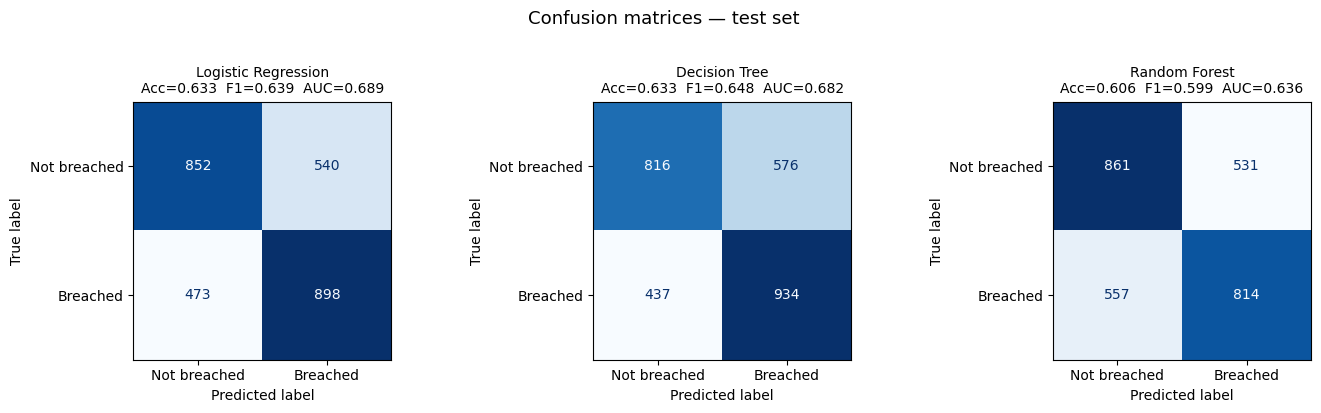

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not breached', 'Breached'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}',
                 fontsize=10)

plt.suptitle('Confusion matrices — test set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC curves

The ROC (Receiver Operating Characteristic) curve plots the **true positive rate** (recall) against the **false positive rate** at every possible classification threshold.

- A model that guesses randomly produces a diagonal line (AUC = 0.5)
- A perfect model hugs the top-left corner (AUC = 1.0)
- The further a curve bows towards the top-left, the better the model discriminates between breached and non-breached organisations

All three curves are shown together so their discriminative ability can be compared directly.

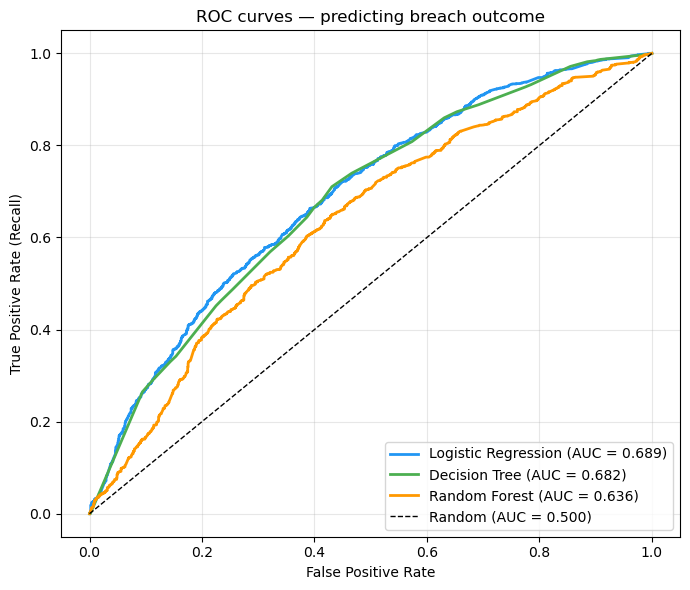

In [9]:
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC curves — predicting breach outcome')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature importance

Which variables best predict breach outcome?

- **Random Forest** provides `feature_importances_` — the mean decrease in impurity across all trees for each feature. Higher = more predictive.
- **Logistic Regression** provides coefficients — positive = increases probability of breach; negative = decreases it. Magnitude indicates strength.

Both are shown side by side. The Random Forest importances are generally more reliable as they capture non-linear relationships; the logistic coefficients are more directly interpretable in direction (positive/negative effect).

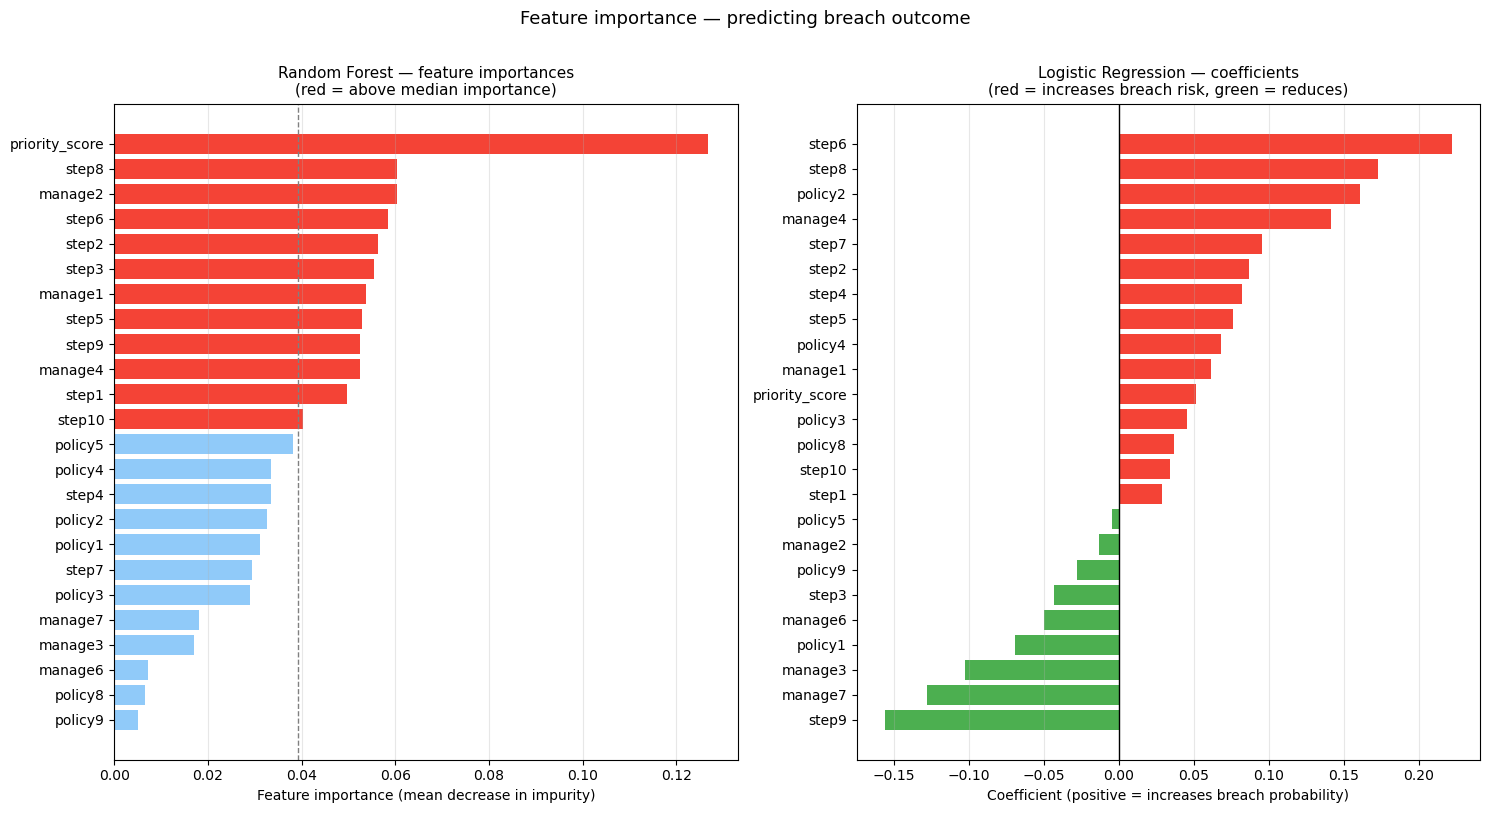


Top 5 most important features (Random Forest):
priority_score    0.1267
step8             0.0605
manage2           0.0603
step6             0.0584
step2             0.0564


In [10]:
rf_model  = results['Random Forest']['model']
lr_model  = results['Logistic Regression']['model']

rf_importance = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
lr_coefs      = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Random Forest — feature importances
ax = axes[0]
colors_rf = ['#F44336' if v > rf_importance.median() else '#90CAF9' for v in rf_importance.values]
ax.barh(rf_importance.index, rf_importance.values, color=colors_rf)
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — feature importances\n(red = above median importance)', fontsize=11)
ax.axvline(rf_importance.median(), color='grey', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')

# Logistic Regression — coefficients
ax = axes[1]
colors_lr = ['#F44336' if v > 0 else '#4CAF50' for v in lr_coefs.values]
ax.barh(lr_coefs.index, lr_coefs.values, color=colors_lr)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (positive = increases breach probability)')
ax.set_title('Logistic Regression — coefficients\n(red = increases breach risk, green = reduces)', fontsize=11)
ax.grid(alpha=0.3, axis='x')

plt.suptitle('Feature importance — predicting breach outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features (Random Forest):")
print(rf_importance.sort_values(ascending=False).head(5).round(4).to_string())

## 11. Performance by year

Because CSBS is repeated cross-sectional data (different respondents each wave), it's worth checking whether model performance is consistent across years. A model trained on all waves should generalise well to each individual wave — if it performs well on some years and poorly on others, that may indicate the relationship between features and breach changed over time.

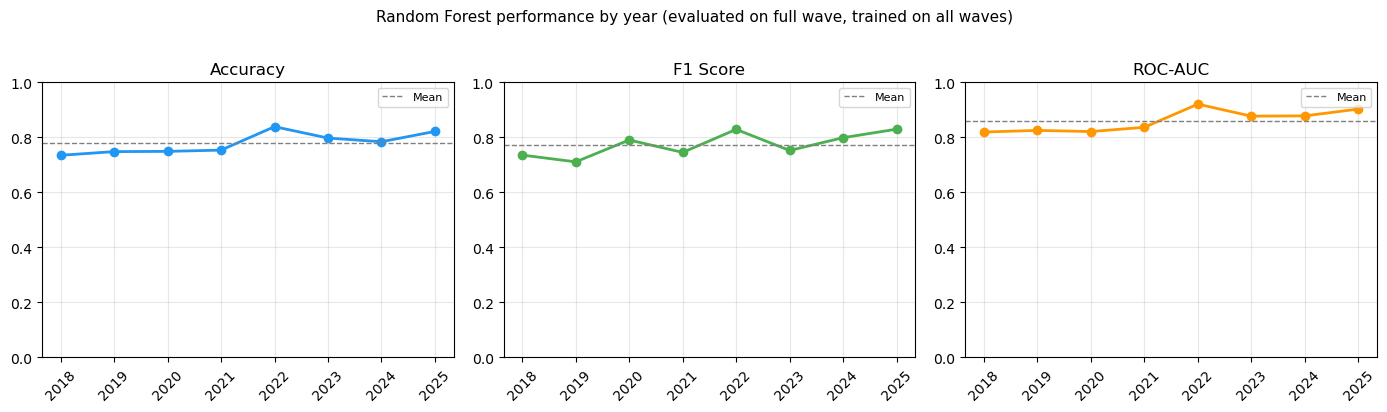


Random Forest performance by year:
         n  accuracy     f1  roc_auc
year                                
2018  1519     0.735  0.735    0.819
2019  1615     0.748  0.711    0.825
2020  1374     0.749  0.790    0.821
2021  1448     0.753  0.745    0.836
2022  1265     0.839  0.829    0.921
2023  2413     0.797  0.752    0.877
2024  2000     0.784  0.799    0.878
2025  2179     0.821  0.830    0.903


In [11]:
# Evaluate best model (Random Forest) on each year separately
rf = results['Random Forest']['model']

year_rows = []
for year in range(2018, 2026):
    mask = combined['year'] == year
    if mask.sum() < 50:
        continue

    X_yr = imputer.transform(combined.loc[mask, FEATURE_COLS].values)
    X_yr = scaler.transform(X_yr)
    y_yr = combined.loc[mask, TARGET_COL].values

    valid = ~np.isnan(y_yr)
    if valid.sum() < 50:
        continue

    y_pred_yr  = rf.predict(X_yr[valid])
    y_proba_yr = rf.predict_proba(X_yr[valid])[:, 1]

    year_rows.append({
        'year':     year,
        'n':        valid.sum(),
        'accuracy': accuracy_score(y_yr[valid], y_pred_yr),
        'f1':       f1_score(y_yr[valid], y_pred_yr),
        'roc_auc':  roc_auc_score(y_yr[valid], y_proba_yr),
    })

year_perf = pd.DataFrame(year_rows).set_index('year')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
metrics = [('accuracy', 'Accuracy', '#2196F3'),
           ('f1',       'F1 Score', '#4CAF50'),
           ('roc_auc',  'ROC-AUC',  '#FF9800')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(year_perf.index, year_perf[col], marker='o', color=color, linewidth=2)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.set_xticks(year_perf.index)
    ax.set_xticklabels(year_perf.index, rotation=45)
    ax.axhline(year_perf[col].mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Random Forest performance by year (evaluated on full wave, trained on all waves)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'sl_performance_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRandom Forest performance by year:")
print(year_perf.round(3).to_string())

## 12. Interpretation and limitations

### What the model tells us
The Random Forest model identifies which governance, policy, and technical control variables are most predictive of breach outcome. Features with high importance (Section 10) are the behaviours most strongly associated with breach risk in the data.

### Important caveats

**Correlation, not causation**  
A high-importance feature predicts breach but does not necessarily cause or prevent it. Organisations that already experienced a breach may have *subsequently* increased their governance scores — if so, the model is partly picking up reactive behaviour rather than predictive risk factors.

**Cross-sectional data**  
CSBS is a snapshot survey — each wave is a different sample of organisations. The model cannot track the same organisation over time, so causal inference is limited.

**Self-reported data**  
Both the features (governance, policy) and the target (breach) are self-reported. Organisations may under-report breaches or over-report governance maturity.

**Class balance**  
Breach rates (~40–58%) are reasonably balanced across waves, so accuracy is a meaningful metric here. In datasets with very skewed targets (e.g. 5% breach rate), accuracy alone would be misleading.

### Academic framing
> *This analysis identifies behavioural correlates of cyber breach outcomes across UK businesses (2018–2025). The Random Forest classifier achieves [X]% accuracy and AUC of [X], suggesting that observable governance and control behaviours have moderate predictive value for breach outcomes — consistent with the hypothesis that cyber security maturity reduces breach risk, while acknowledging the limitations of cross-sectional self-reported data.*